## Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import (
    StratifiedKFold, LeaveOneGroupOut,
    cross_validate, cross_val_predict, cross_val_score,
)
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import pacmap

from sklearn.metrics import f1_score, roc_auc_score
import shap
shap.initjs()

/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load data

In [2]:
TEST_SIZE = 0.3

In [3]:
# Load gex_mat_corrected
gex_mat = pd.read_csv(f"../dataset/created/gex_mat_corrected.csv").set_index('sample_id').T
gex_mat['sample_id'] = gex_mat.index

print(gex_mat.shape)
gex_mat.head()

(93, 23387)


sample_id,A1BG-AS1,A1CF,A2M-AS1,A2ML1,A3GALT2,A4GALT,A4GNT,AA06,AAAS,AACS,...,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,sample_id
03660555B,0.939876,-0.011136,2.716936,-0.002742,-0.235660,2.159839,-0.199243,0.0,5.544891,3.029141,...,3.119797,0.579489,1.197027,2.767412,0.067917,2.075334,6.520917,2.901888,2.936871,03660555B
03660598B,1.297554,-0.018419,4.021754,0.263323,-0.105383,1.490465,-0.013174,0.0,5.487184,3.181414,...,3.527217,0.719643,1.047121,2.605837,0.011788,2.428301,5.592390,2.916066,2.584241,03660598B
03660602B,1.384195,-0.011445,3.021708,0.175630,-0.107922,1.721015,0.325756,0.0,4.824042,2.215764,...,2.881696,0.729726,1.071112,2.494103,0.275479,2.212807,6.502476,3.108193,3.461181,03660602B
04240076F,0.743205,-0.016362,2.441745,0.583390,-0.187688,3.006412,0.049957,0.0,4.526621,2.434363,...,2.740178,0.819844,1.070239,2.402288,-0.012119,2.043461,6.665068,3.081927,2.229877,04240076F
04240106F,1.225270,-0.027412,2.687662,0.026337,0.679702,1.774998,-0.164307,0.0,5.652413,2.143562,...,1.843524,0.832736,1.341150,2.885113,-0.037118,2.843567,5.521338,3.266616,3.503077,04240106F


In [4]:
# Load clinical_gex
clinical_gex = pd.read_csv(f"../dataset/created/clinical_gex.csv", low_memory=False)

print(clinical_gex.shape)
clinical_gex.head()

(93, 51483)


,patientID,sex,age,AJCC_stage,M_stage,LDH,immunotherapy_treatment,pre_MAPKi_treatment,source,pfs_label,...,sept-05,sept-06,sept-07,sept-08,sept-09,sept-10,sept-11,sept-12,sept-14,sept-15
0,YR_3053,male,26,IV,M1B,elevated,no,no,Yan et al.,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,YR_3708,female,58,IV,M1A,normal,no,no,Yan et al.,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,YR_3705,male,45,IV,M1A,normal,no,no,Yan et al.,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,YR_1106,male,48,IIIC,NaN,normal,no,no,Yan et al.,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,YR_1110,male,33,IV,M1C,normal,no,no,Yan et al.,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Clinical feature groups
clinical_ordinal_col    = ['M_stage']
clinical_categorical_cols = ['sex', 'AJCC_stage', 'LDH', 'immunotherapy_treatment', 'pre_MAPKi_treatment']
clinical_numeric_col    = ['age']
clinical_drug_braf_cols = ['cobimetinib', 'trametinib', 'dabrafenib', 'vemurafenib',
                           'C195W', 'K601I', 'MND', 'V600E', 'V600K', 'V600R'] 
clinical_remaining_cols = ['patientID', 'sample_id', 'pfs_label', 'source']

In [6]:
# sometime certain drugs or gene are missing in the dataset
clinical_drug_braf_cols = [c for c in clinical_drug_braf_cols if c in clinical_gex.columns]

CLINICAL_COLS = (clinical_ordinal_col + clinical_categorical_cols + clinical_numeric_col
                + clinical_drug_braf_cols + clinical_remaining_cols)

GEX_COLS_ORI = [c for c in clinical_gex.columns if c not in CLINICAL_COLS]

print('Original clinical_gex features:')
print(f'clinical + gex = {len(CLINICAL_COLS)} + {len(GEX_COLS_ORI)} = {len(CLINICAL_COLS)+len(GEX_COLS_ORI)}')

Original clinical_gex features:
clinical + gex = 18 + 51465 = 51483


In [7]:
# Merge into clinical_gex_corrected
clinical_gex_filtered = clinical_gex[CLINICAL_COLS]
clinical_gex_filtered

clinical_gex_filtered = clinical_gex_filtered.merge(gex_mat, on='sample_id', how='inner')
print(clinical_gex_filtered.shape)
clinical_gex_filtered.head()

(93, 23404)


,M_stage,sex,AJCC_stage,LDH,immunotherapy_treatment,pre_MAPKi_treatment,age,cobimetinib,trametinib,dabrafenib,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
0,M1B,male,IV,elevated,no,no,26,0,0,0,...,2.691370,3.119797,0.579489,1.197027,2.767412,0.067917,2.075334,6.520917,2.901888,2.936871
1,M1A,female,IV,normal,no,no,58,0,0,0,...,2.992909,3.527217,0.719643,1.047121,2.605837,0.011788,2.428301,5.592390,2.916066,2.584241
2,M1A,male,IV,normal,no,no,45,0,0,0,...,3.671846,2.881696,0.729726,1.071112,2.494103,0.275479,2.212807,6.502476,3.108193,3.461181
3,NaN,male,IIIC,normal,no,no,48,1,0,0,...,2.380165,2.740178,0.819844,1.070239,2.402288,-0.012119,2.043461,6.665068,3.081927,2.229877
4,M1C,male,IV,normal,no,no,33,1,0,0,...,3.024410,1.843524,0.832736,1.341150,2.885113,-0.037118,2.843567,5.521338,3.266616,3.503077


In [8]:
GEX_COLS_FILTERED = [c for c in clinical_gex_filtered.columns if c not in CLINICAL_COLS]

print('Filtered clinical_gex features:')
print(f'clinical + gex = {len(CLINICAL_COLS)} + {len(GEX_COLS_FILTERED)} = {len(CLINICAL_COLS)+len(GEX_COLS_FILTERED)}')

Filtered clinical_gex features:
clinical + gex = 18 + 23386 = 23404


In [9]:
from sklearn.model_selection import train_test_split

# Split x, y
clinical_gex_filtered.columns = clinical_gex_filtered.columns.str.strip()

y = clinical_gex_filtered['pfs_label']
x = clinical_gex_filtered.drop(clinical_remaining_cols, axis=1)

print(f'Dropped {len(clinical_remaining_cols)} clinical cols, {x.shape} remaining')
x.head()

Dropped 4 clinical cols, (93, 23400) remaining


,M_stage,sex,AJCC_stage,LDH,immunotherapy_treatment,pre_MAPKi_treatment,age,cobimetinib,trametinib,dabrafenib,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
0,M1B,male,IV,elevated,no,no,26,0,0,0,...,2.691370,3.119797,0.579489,1.197027,2.767412,0.067917,2.075334,6.520917,2.901888,2.936871
1,M1A,female,IV,normal,no,no,58,0,0,0,...,2.992909,3.527217,0.719643,1.047121,2.605837,0.011788,2.428301,5.592390,2.916066,2.584241
2,M1A,male,IV,normal,no,no,45,0,0,0,...,3.671846,2.881696,0.729726,1.071112,2.494103,0.275479,2.212807,6.502476,3.108193,3.461181
3,NaN,male,IIIC,normal,no,no,48,1,0,0,...,2.380165,2.740178,0.819844,1.070239,2.402288,-0.012119,2.043461,6.665068,3.081927,2.229877
4,M1C,male,IV,normal,no,no,33,1,0,0,...,3.024410,1.843524,0.832736,1.341150,2.885113,-0.037118,2.843567,5.521338,3.266616,3.503077


In [10]:
print(f"\nTarget distribution:\n{y.value_counts().sort_index()}")


Target distribution:
pfs_label
0    47
1    46
Name: count, dtype: int64


## Preprocessing Pipeline

In [11]:
preprocess_features = ColumnTransformer(
    transformers=[
        ('m_stage', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OrdinalEncoder(
                categories=[['M1A', 'M1B', 'M1C']],
                handle_unknown='use_encoded_value',
                unknown_value=np.nan,
            )),
        ]), clinical_ordinal_col),

        ('categorical', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore')),
        ]), clinical_categorical_cols),

        ('age',      SimpleImputer(strategy='median'), clinical_numeric_col),
        ('drug_braf', 'passthrough',                   clinical_drug_braf_cols),

        ('gex', Pipeline([
            ('variance', VarianceThreshold(threshold=0.1)),
            ('kbest',    SelectKBest(f_classif, k=500)),
        ]), GEX_COLS_FILTERED),
    ],
    remainder='drop',
)

In [12]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_clf = LogisticRegression(
    solver='saga',
    class_weight='balanced',
    max_iter=5000,
    random_state=42,
)

rfe = RFE(
    estimator=RandomForestClassifier(n_estimators=100, random_state=42),
    step=0.1,
    n_features_to_select=10,
)

full_pipe = Pipeline([
    ('preprocess', preprocess_features),
    # ('selection', rfe),
    ('scaler', StandardScaler()),
    ('clf', lr_clf)
])

In [13]:
def objective(trial):
    params = {
            'clf__C':        trial.suggest_float('clf__C', 1e-5, 10.0, log=True),
            'clf__l1_ratio': trial.suggest_categorical('clf__l1_ratio', [0.0, 1.0]),
            'preprocess__gex__kbest__k': trial.suggest_int('preprocess__gex__kbest__k', 20, 100)
        }
    
    full_pipe.set_params(**params)
    scores = cross_val_score(full_pipe, x, y, cv=skf, scoring='f1', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(study.best_params)
print(f"Best CV F1: {study.best_value:.3f}")

[I 2026-05-05 16:03:07,618] A new study created in memory with name: no-name-6405d094-c73d-4595-a87b-388f5275bf4a
Best trial: 0. Best value: 0.51634:   1%|          | 1/100 [00:02<03:47,  2.30s/it]

[I 2026-05-05 16:03:09,932] Trial 0 finished with value: 0.5163398692810458 and parameters: {'clf__C': 0.0017670169402947942, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 68}. Best is trial 0 with value: 0.5163398692810458.


Best trial: 0. Best value: 0.51634:   2%|▏         | 2/100 [00:03<03:02,  1.86s/it]

[I 2026-05-05 16:03:11,495] Trial 1 finished with value: 0.43607291401409043 and parameters: {'clf__C': 8.632008168602535e-05, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 90}. Best is trial 0 with value: 0.5163398692810458.


Best trial: 2. Best value: 0.553655:   3%|▎         | 3/100 [00:05<02:50,  1.76s/it]

[I 2026-05-05 16:03:13,121] Trial 2 finished with value: 0.5536549707602338 and parameters: {'clf__C': 0.040428727350273294, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 98}. Best is trial 2 with value: 0.5536549707602338.


Best trial: 3. Best value: 0.651813:   4%|▍         | 4/100 [00:07<02:44,  1.72s/it]

[I 2026-05-05 16:03:14,780] Trial 3 finished with value: 0.6518128654970761 and parameters: {'clf__C': 0.9877700294007905, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 34}. Best is trial 3 with value: 0.6518128654970761.


Best trial: 3. Best value: 0.651813:   5%|▌         | 5/100 [00:07<02:02,  1.29s/it]

[I 2026-05-05 16:03:15,324] Trial 4 finished with value: 0.5244444444444445 and parameters: {'clf__C': 0.0006690421166498799, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 43}. Best is trial 3 with value: 0.6518128654970761.


Best trial: 3. Best value: 0.651813:   6%|▌         | 6/100 [00:08<01:36,  1.02s/it]

[I 2026-05-05 16:03:15,816] Trial 5 finished with value: 0.3952380952380953 and parameters: {'clf__C': 0.046894009635376876, 'clf__l1_ratio': 1.0, 'preprocess__gex__kbest__k': 49}. Best is trial 3 with value: 0.6518128654970761.


Best trial: 3. Best value: 0.651813:   7%|▋         | 7/100 [00:08<01:18,  1.18it/s]

[I 2026-05-05 16:03:16,305] Trial 6 finished with value: 0.5118954248366012 and parameters: {'clf__C': 0.0054502936945582505, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 61}. Best is trial 3 with value: 0.6518128654970761.


Best trial: 3. Best value: 0.651813:   8%|▊         | 8/100 [00:09<01:07,  1.37it/s]

[I 2026-05-05 16:03:16,790] Trial 7 finished with value: 0.2619047619047619 and parameters: {'clf__C': 0.035849855803404725, 'clf__l1_ratio': 1.0, 'preprocess__gex__kbest__k': 33}. Best is trial 3 with value: 0.6518128654970761.


Best trial: 3. Best value: 0.651813:   9%|▉         | 9/100 [00:09<00:59,  1.52it/s]

[I 2026-05-05 16:03:17,283] Trial 8 finished with value: 0.2619047619047619 and parameters: {'clf__C': 2.4564592152507503e-05, 'clf__l1_ratio': 1.0, 'preprocess__gex__kbest__k': 85}. Best is trial 3 with value: 0.6518128654970761.


Best trial: 3. Best value: 0.651813:  10%|█         | 10/100 [00:10<00:54,  1.65it/s]

[I 2026-05-05 16:03:17,777] Trial 9 finished with value: 0.2619047619047619 and parameters: {'clf__C': 0.0006724850206557243, 'clf__l1_ratio': 1.0, 'preprocess__gex__kbest__k': 55}. Best is trial 3 with value: 0.6518128654970761.


Best trial: 10. Best value: 0.679522:  11%|█         | 11/100 [00:10<00:50,  1.75it/s]

[I 2026-05-05 16:03:18,266] Trial 10 finished with value: 0.6795223352498894 and parameters: {'clf__C': 4.686183228417117, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 20}. Best is trial 10 with value: 0.6795223352498894.


Best trial: 11. Best value: 0.719649:  12%|█▏        | 12/100 [00:11<00:48,  1.81it/s]

[I 2026-05-05 16:03:18,774] Trial 11 finished with value: 0.7196491228070174 and parameters: {'clf__C': 5.198134835453529, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 23}. Best is trial 11 with value: 0.7196491228070174.


Best trial: 11. Best value: 0.719649:  13%|█▎        | 13/100 [00:11<00:46,  1.86it/s]

[I 2026-05-05 16:03:19,283] Trial 12 finished with value: 0.651702786377709 and parameters: {'clf__C': 8.28248694215195, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 21}. Best is trial 11 with value: 0.7196491228070174.


Best trial: 11. Best value: 0.719649:  14%|█▍        | 14/100 [00:12<00:45,  1.90it/s]

[I 2026-05-05 16:03:19,783] Trial 13 finished with value: 0.6661890019165562 and parameters: {'clf__C': 9.650018108948377, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 20}. Best is trial 11 with value: 0.7196491228070174.


Best trial: 11. Best value: 0.719649:  15%|█▌        | 15/100 [00:12<00:44,  1.92it/s]

[I 2026-05-05 16:03:20,288] Trial 14 finished with value: 0.6746411483253589 and parameters: {'clf__C': 0.6160702485755014, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 31}. Best is trial 11 with value: 0.7196491228070174.


Best trial: 11. Best value: 0.719649:  16%|█▌        | 16/100 [00:13<00:42,  1.96it/s]

[I 2026-05-05 16:03:20,772] Trial 15 finished with value: 0.6030284043441938 and parameters: {'clf__C': 0.9090766298669165, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 41}. Best is trial 11 with value: 0.7196491228070174.


Best trial: 11. Best value: 0.719649:  17%|█▋        | 17/100 [00:13<00:42,  1.97it/s]

[I 2026-05-05 16:03:21,275] Trial 16 finished with value: 0.5876900584795322 and parameters: {'clf__C': 0.298420607008903, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 72}. Best is trial 11 with value: 0.7196491228070174.


Best trial: 11. Best value: 0.719649:  18%|█▊        | 18/100 [00:14<00:41,  1.99it/s]

[I 2026-05-05 16:03:21,770] Trial 17 finished with value: 0.6663203463203463 and parameters: {'clf__C': 3.511164685813565, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 26}. Best is trial 11 with value: 0.7196491228070174.


Best trial: 11. Best value: 0.719649:  19%|█▉        | 19/100 [00:14<00:40,  1.99it/s]

[I 2026-05-05 16:03:22,273] Trial 18 finished with value: 0.5684308811243797 and parameters: {'clf__C': 0.16105550442018984, 'clf__l1_ratio': 1.0, 'preprocess__gex__kbest__k': 40}. Best is trial 11 with value: 0.7196491228070174.


Best trial: 11. Best value: 0.719649:  20%|██        | 20/100 [00:15<00:40,  1.96it/s]

[I 2026-05-05 16:03:22,798] Trial 19 finished with value: 0.6485903591032142 and parameters: {'clf__C': 3.386750078512401, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 28}. Best is trial 11 with value: 0.7196491228070174.


Best trial: 11. Best value: 0.719649:  21%|██        | 21/100 [00:15<00:40,  1.97it/s]

[I 2026-05-05 16:03:23,297] Trial 20 finished with value: 0.611812865497076 and parameters: {'clf__C': 2.166860017318628, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 55}. Best is trial 11 with value: 0.7196491228070174.


Best trial: 11. Best value: 0.719649:  22%|██▏       | 22/100 [00:16<00:39,  1.98it/s]

[I 2026-05-05 16:03:23,799] Trial 21 finished with value: 0.6833333333333333 and parameters: {'clf__C': 0.2689842597414461, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 30}. Best is trial 11 with value: 0.7196491228070174.


Best trial: 11. Best value: 0.719649:  23%|██▎       | 23/100 [00:16<00:38,  1.99it/s]

[I 2026-05-05 16:03:24,295] Trial 22 finished with value: 0.6560985797827903 and parameters: {'clf__C': 0.23933652285348572, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 21}. Best is trial 11 with value: 0.7196491228070174.


Best trial: 11. Best value: 0.719649:  24%|██▍       | 24/100 [00:17<00:38,  1.99it/s]

[I 2026-05-05 16:03:24,795] Trial 23 finished with value: 0.6391812865497075 and parameters: {'clf__C': 1.895324429251899, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 38}. Best is trial 11 with value: 0.7196491228070174.


Best trial: 11. Best value: 0.719649:  25%|██▌       | 25/100 [00:17<00:37,  2.00it/s]

[I 2026-05-05 16:03:25,293] Trial 24 finished with value: 0.6533333333333332 and parameters: {'clf__C': 0.11336444120028022, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 26}. Best is trial 11 with value: 0.7196491228070174.


Best trial: 11. Best value: 0.719649:  26%|██▌       | 26/100 [00:18<00:37,  1.98it/s]

[I 2026-05-05 16:03:25,808] Trial 25 finished with value: 0.648093763821318 and parameters: {'clf__C': 9.069192742539162, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 48}. Best is trial 11 with value: 0.7196491228070174.


Best trial: 11. Best value: 0.719649:  27%|██▋       | 27/100 [00:18<00:37,  1.95it/s]

[I 2026-05-05 16:03:26,340] Trial 26 finished with value: 0.6759958720330237 and parameters: {'clf__C': 0.5138869017040353, 'clf__l1_ratio': 1.0, 'preprocess__gex__kbest__k': 27}. Best is trial 11 with value: 0.7196491228070174.


Best trial: 11. Best value: 0.719649:  28%|██▊       | 28/100 [00:19<00:36,  1.97it/s]

[I 2026-05-05 16:03:26,833] Trial 27 finished with value: 0.5977554179566563 and parameters: {'clf__C': 0.009032360273921902, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 35}. Best is trial 11 with value: 0.7196491228070174.


Best trial: 11. Best value: 0.719649:  29%|██▉       | 29/100 [00:19<00:35,  1.98it/s]

[I 2026-05-05 16:03:27,330] Trial 28 finished with value: 0.698345864661654 and parameters: {'clf__C': 1.9949218240603215, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 20}. Best is trial 11 with value: 0.7196491228070174.


Best trial: 11. Best value: 0.719649:  30%|███       | 30/100 [00:20<00:35,  1.95it/s]

[I 2026-05-05 16:03:27,862] Trial 29 finished with value: 0.6251461988304093 and parameters: {'clf__C': 1.3669557518687983, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 66}. Best is trial 11 with value: 0.7196491228070174.


Best trial: 11. Best value: 0.719649:  31%|███       | 31/100 [00:20<00:35,  1.97it/s]

[I 2026-05-05 16:03:28,358] Trial 30 finished with value: 0.6097953216374268 and parameters: {'clf__C': 0.13663365404092612, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 47}. Best is trial 11 with value: 0.7196491228070174.


Best trial: 11. Best value: 0.719649:  32%|███▏      | 32/100 [00:21<00:34,  1.99it/s]

[I 2026-05-05 16:03:28,852] Trial 31 finished with value: 0.7141353383458646 and parameters: {'clf__C': 2.826339205014262, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 20}. Best is trial 11 with value: 0.7196491228070174.


Best trial: 11. Best value: 0.719649:  33%|███▎      | 33/100 [00:21<00:33,  2.00it/s]

[I 2026-05-05 16:03:29,341] Trial 32 finished with value: 0.6740350877192983 and parameters: {'clf__C': 0.41509734354260813, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 25}. Best is trial 11 with value: 0.7196491228070174.


Best trial: 11. Best value: 0.719649:  34%|███▍      | 34/100 [00:22<00:32,  2.01it/s]

[I 2026-05-05 16:03:29,833] Trial 33 finished with value: 0.7086625985252988 and parameters: {'clf__C': 2.196308281239478, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 30}. Best is trial 11 with value: 0.7196491228070174.


Best trial: 11. Best value: 0.719649:  35%|███▌      | 35/100 [00:22<00:32,  2.01it/s]

[I 2026-05-05 16:03:30,328] Trial 34 finished with value: 0.6548606811145511 and parameters: {'clf__C': 1.6637079004611381, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 36}. Best is trial 11 with value: 0.7196491228070174.


Best trial: 11. Best value: 0.719649:  36%|███▌      | 36/100 [00:23<00:32,  1.99it/s]

[I 2026-05-05 16:03:30,845] Trial 35 finished with value: 0.6107602339181286 and parameters: {'clf__C': 3.4331373191197807, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 78}. Best is trial 11 with value: 0.7196491228070174.


Best trial: 11. Best value: 0.719649:  37%|███▋      | 37/100 [00:23<00:31,  2.02it/s]

[I 2026-05-05 16:03:31,326] Trial 36 finished with value: 0.6444444444444444 and parameters: {'clf__C': 0.06066585506438809, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 24}. Best is trial 11 with value: 0.7196491228070174.


Best trial: 11. Best value: 0.719649:  38%|███▊      | 38/100 [00:24<00:30,  2.04it/s]

[I 2026-05-05 16:03:31,806] Trial 37 finished with value: 0.54640522875817 and parameters: {'clf__C': 0.0026572396251753317, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 33}. Best is trial 11 with value: 0.7196491228070174.


Best trial: 11. Best value: 0.719649:  39%|███▉      | 39/100 [00:24<00:29,  2.05it/s]

[I 2026-05-05 16:03:32,284] Trial 38 finished with value: 0.2619047619047619 and parameters: {'clf__C': 0.026922085501817718, 'clf__l1_ratio': 1.0, 'preprocess__gex__kbest__k': 45}. Best is trial 11 with value: 0.7196491228070174.


Best trial: 11. Best value: 0.719649:  40%|████      | 40/100 [00:25<00:29,  2.04it/s]

[I 2026-05-05 16:03:32,779] Trial 39 finished with value: 0.5244444444444445 and parameters: {'clf__C': 0.0001679182572178052, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 31}. Best is trial 11 with value: 0.7196491228070174.


Best trial: 11. Best value: 0.719649:  41%|████      | 41/100 [00:25<00:29,  2.03it/s]

[I 2026-05-05 16:03:33,283] Trial 40 finished with value: 0.6095798319327731 and parameters: {'clf__C': 0.8105730330975623, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 100}. Best is trial 11 with value: 0.7196491228070174.


Best trial: 11. Best value: 0.719649:  42%|████▏     | 42/100 [00:26<00:29,  1.95it/s]

[I 2026-05-05 16:03:33,837] Trial 41 finished with value: 0.6353739848342081 and parameters: {'clf__C': 3.815149774688445, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 29}. Best is trial 11 with value: 0.7196491228070174.


Best trial: 11. Best value: 0.719649:  43%|████▎     | 43/100 [00:26<00:28,  1.97it/s]

[I 2026-05-05 16:03:34,330] Trial 42 finished with value: 0.6977777777777778 and parameters: {'clf__C': 1.3018126877774874, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 23}. Best is trial 11 with value: 0.7196491228070174.


Best trial: 11. Best value: 0.719649:  44%|████▍     | 44/100 [00:27<00:28,  1.98it/s]

[I 2026-05-05 16:03:34,829] Trial 43 finished with value: 0.6977777777777778 and parameters: {'clf__C': 1.2263426753811568, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 23}. Best is trial 11 with value: 0.7196491228070174.


Best trial: 11. Best value: 0.719649:  45%|████▌     | 45/100 [00:27<00:27,  1.99it/s]

[I 2026-05-05 16:03:35,326] Trial 44 finished with value: 0.6795223352498894 and parameters: {'clf__C': 6.4838094129520325, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 20}. Best is trial 11 with value: 0.7196491228070174.


Best trial: 11. Best value: 0.719649:  46%|████▌     | 46/100 [00:28<00:28,  1.90it/s]

[I 2026-05-05 16:03:35,909] Trial 45 finished with value: 0.6760332203056661 and parameters: {'clf__C': 1.870901250299813, 'clf__l1_ratio': 1.0, 'preprocess__gex__kbest__k': 91}. Best is trial 11 with value: 0.7196491228070174.


Best trial: 11. Best value: 0.719649:  47%|████▋     | 47/100 [00:28<00:27,  1.94it/s]

[I 2026-05-05 16:03:36,400] Trial 46 finished with value: 0.6792815371762739 and parameters: {'clf__C': 0.7591557251480925, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 24}. Best is trial 11 with value: 0.7196491228070174.


Best trial: 11. Best value: 0.719649:  48%|████▊     | 48/100 [00:29<00:26,  1.98it/s]

[I 2026-05-05 16:03:36,883] Trial 47 finished with value: 0.6028207774337806 and parameters: {'clf__C': 0.01787510163701493, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 36}. Best is trial 11 with value: 0.7196491228070174.


Best trial: 11. Best value: 0.719649:  49%|████▉     | 49/100 [00:29<00:25,  1.98it/s]

[I 2026-05-05 16:03:37,386] Trial 48 finished with value: 0.6123186754765702 and parameters: {'clf__C': 5.399869448176969, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 53}. Best is trial 11 with value: 0.7196491228070174.


Best trial: 11. Best value: 0.719649:  50%|█████     | 50/100 [00:30<00:25,  1.96it/s]

[I 2026-05-05 16:03:37,904] Trial 49 finished with value: 0.6964456596035543 and parameters: {'clf__C': 2.6241012515205697, 'clf__l1_ratio': 1.0, 'preprocess__gex__kbest__k': 32}. Best is trial 11 with value: 0.7196491228070174.


Best trial: 50. Best value: 0.726667:  51%|█████     | 51/100 [00:30<00:24,  1.97it/s]

[I 2026-05-05 16:03:38,408] Trial 50 finished with value: 0.7266666666666666 and parameters: {'clf__C': 9.90286508884728, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 23}. Best is trial 50 with value: 0.7266666666666666.


Best trial: 50. Best value: 0.726667:  52%|█████▏    | 52/100 [00:31<00:24,  1.99it/s]

[I 2026-05-05 16:03:38,899] Trial 51 finished with value: 0.7266666666666666 and parameters: {'clf__C': 9.370567875571231, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 23}. Best is trial 50 with value: 0.7266666666666666.


Best trial: 50. Best value: 0.726667:  53%|█████▎    | 53/100 [00:31<00:23,  2.00it/s]

[I 2026-05-05 16:03:39,390] Trial 52 finished with value: 0.6486451422674333 and parameters: {'clf__C': 8.433186647236035, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 20}. Best is trial 50 with value: 0.7266666666666666.


Best trial: 50. Best value: 0.726667:  54%|█████▍    | 54/100 [00:32<00:23,  2.00it/s]

[I 2026-05-05 16:03:39,894] Trial 53 finished with value: 0.6637950374657872 and parameters: {'clf__C': 5.145065810150403, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 28}. Best is trial 50 with value: 0.7266666666666666.


Best trial: 50. Best value: 0.726667:  55%|█████▌    | 55/100 [00:32<00:22,  2.01it/s]

[I 2026-05-05 16:03:40,383] Trial 54 finished with value: 0.4728937728937729 and parameters: {'clf__C': 1.5147946435695302e-05, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 29}. Best is trial 50 with value: 0.7266666666666666.


Best trial: 50. Best value: 0.726667:  56%|█████▌    | 56/100 [00:33<00:22,  1.94it/s]

[I 2026-05-05 16:03:40,940] Trial 55 finished with value: 0.7266666666666666 and parameters: {'clf__C': 9.956766392222804, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 23}. Best is trial 50 with value: 0.7266666666666666.


Best trial: 50. Best value: 0.726667:  57%|█████▋    | 57/100 [00:33<00:22,  1.95it/s]

[I 2026-05-05 16:03:41,449] Trial 56 finished with value: 0.6758107389686338 and parameters: {'clf__C': 5.709548867204968, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 39}. Best is trial 50 with value: 0.7266666666666666.


Best trial: 50. Best value: 0.726667:  58%|█████▊    | 58/100 [00:34<00:21,  1.95it/s]

[I 2026-05-05 16:03:41,961] Trial 57 finished with value: 0.7266666666666666 and parameters: {'clf__C': 9.179622446122575, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 23}. Best is trial 50 with value: 0.7266666666666666.


Best trial: 50. Best value: 0.726667:  59%|█████▉    | 59/100 [00:34<00:20,  1.97it/s]

[I 2026-05-05 16:03:42,459] Trial 58 finished with value: 0.7266666666666666 and parameters: {'clf__C': 9.065082661054348, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 23}. Best is trial 50 with value: 0.7266666666666666.


Best trial: 50. Best value: 0.726667:  60%|██████    | 60/100 [00:35<00:21,  1.89it/s]

[I 2026-05-05 16:03:43,032] Trial 59 finished with value: 0.6092289547397907 and parameters: {'clf__C': 9.149377293172892, 'clf__l1_ratio': 1.0, 'preprocess__gex__kbest__k': 42}. Best is trial 50 with value: 0.7266666666666666.


Best trial: 50. Best value: 0.726667:  61%|██████    | 61/100 [00:35<00:20,  1.93it/s]

[I 2026-05-05 16:03:43,528] Trial 60 finished with value: 0.6803554340396445 and parameters: {'clf__C': 4.686822829414096, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 26}. Best is trial 50 with value: 0.7266666666666666.


Best trial: 50. Best value: 0.726667:  62%|██████▏   | 62/100 [00:36<00:19,  1.92it/s]

[I 2026-05-05 16:03:44,057] Trial 61 finished with value: 0.6869218500797448 and parameters: {'clf__C': 9.523264427664875, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 22}. Best is trial 50 with value: 0.7266666666666666.


Best trial: 50. Best value: 0.726667:  63%|██████▎   | 63/100 [00:36<00:19,  1.95it/s]

[I 2026-05-05 16:03:44,553] Trial 62 finished with value: 0.7006060606060606 and parameters: {'clf__C': 3.4699675894790025, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 25}. Best is trial 50 with value: 0.7266666666666666.


Best trial: 50. Best value: 0.726667:  64%|██████▍   | 64/100 [00:37<00:18,  1.96it/s]

[I 2026-05-05 16:03:45,053] Trial 63 finished with value: 0.7196491228070174 and parameters: {'clf__C': 5.7115284214333375, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 23}. Best is trial 50 with value: 0.7266666666666666.


Best trial: 50. Best value: 0.726667:  65%|██████▌   | 65/100 [00:37<00:17,  1.97it/s]

[I 2026-05-05 16:03:45,553] Trial 64 finished with value: 0.6835885167464115 and parameters: {'clf__C': 5.7707952825653805, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 33}. Best is trial 50 with value: 0.7266666666666666.


Best trial: 50. Best value: 0.726667:  66%|██████▌   | 66/100 [00:38<00:17,  1.97it/s]

[I 2026-05-05 16:03:46,063] Trial 65 finished with value: 0.6564266164131556 and parameters: {'clf__C': 7.143306054412854, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 28}. Best is trial 50 with value: 0.7266666666666666.


Best trial: 50. Best value: 0.726667:  67%|██████▋   | 67/100 [00:38<00:16,  1.98it/s]

[I 2026-05-05 16:03:46,566] Trial 66 finished with value: 0.7266666666666666 and parameters: {'clf__C': 9.76662291172995, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 23}. Best is trial 50 with value: 0.7266666666666666.


Best trial: 50. Best value: 0.726667:  68%|██████▊   | 68/100 [00:39<00:16,  1.96it/s]

[I 2026-05-05 16:03:47,082] Trial 67 finished with value: 0.672285258601048 and parameters: {'clf__C': 9.592872762578008, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 26}. Best is trial 50 with value: 0.7266666666666666.


Best trial: 50. Best value: 0.726667:  69%|██████▉   | 69/100 [00:39<00:15,  1.97it/s]

[I 2026-05-05 16:03:47,588] Trial 68 finished with value: 0.6674922600619195 and parameters: {'clf__C': 3.01166388638917, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 35}. Best is trial 50 with value: 0.7266666666666666.


Best trial: 69. Best value: 0.733589:  70%|███████   | 70/100 [00:40<00:15,  1.99it/s]

[I 2026-05-05 16:03:48,078] Trial 69 finished with value: 0.7335885167464115 and parameters: {'clf__C': 3.902349376271466, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 23}. Best is trial 69 with value: 0.7335885167464115.


Best trial: 69. Best value: 0.733589:  71%|███████   | 71/100 [00:40<00:14,  1.96it/s]

[I 2026-05-05 16:03:48,603] Trial 70 finished with value: 0.6633993182599994 and parameters: {'clf__C': 1.0200727582258078, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 27}. Best is trial 69 with value: 0.7335885167464115.


Best trial: 69. Best value: 0.733589:  72%|███████▏  | 72/100 [00:41<00:14,  1.97it/s]

[I 2026-05-05 16:03:49,104] Trial 71 finished with value: 0.720956937799043 and parameters: {'clf__C': 4.621358764739886, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 22}. Best is trial 69 with value: 0.7335885167464115.


Best trial: 69. Best value: 0.733589:  73%|███████▎  | 73/100 [00:41<00:13,  1.99it/s]

[I 2026-05-05 16:03:49,599] Trial 72 finished with value: 0.720956937799043 and parameters: {'clf__C': 4.291750053112134, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 22}. Best is trial 69 with value: 0.7335885167464115.


Best trial: 69. Best value: 0.733589:  74%|███████▍  | 74/100 [00:42<00:13,  1.99it/s]

[I 2026-05-05 16:03:50,099] Trial 73 finished with value: 0.7035885167464115 and parameters: {'clf__C': 2.469909421373092, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 31}. Best is trial 69 with value: 0.7335885167464115.


Best trial: 69. Best value: 0.733589:  75%|███████▌  | 75/100 [00:42<00:12,  1.97it/s]

[I 2026-05-05 16:03:50,616] Trial 74 finished with value: 0.49687134502923974 and parameters: {'clf__C': 0.0007689476637459621, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 63}. Best is trial 69 with value: 0.7335885167464115.


Best trial: 69. Best value: 0.733589:  76%|███████▌  | 76/100 [00:43<00:12,  1.98it/s]

[I 2026-05-05 16:03:51,121] Trial 75 finished with value: 0.6799043062200957 and parameters: {'clf__C': 9.960269581070952, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 25}. Best is trial 69 with value: 0.7335885167464115.


Best trial: 69. Best value: 0.733589:  77%|███████▋  | 77/100 [00:43<00:11,  1.99it/s]

[I 2026-05-05 16:03:51,612] Trial 76 finished with value: 0.5488336225178331 and parameters: {'clf__C': 7.149615384600165e-05, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 22}. Best is trial 69 with value: 0.7335885167464115.


Best trial: 69. Best value: 0.733589:  78%|███████▊  | 78/100 [00:44<00:10,  2.01it/s]

[I 2026-05-05 16:03:52,103] Trial 77 finished with value: 0.6551263068156324 and parameters: {'clf__C': 3.856282339336287, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 28}. Best is trial 69 with value: 0.7335885167464115.


Best trial: 69. Best value: 0.733589:  79%|███████▉  | 79/100 [00:45<00:11,  1.86it/s]

[I 2026-05-05 16:03:52,728] Trial 78 finished with value: 0.6236119711042312 and parameters: {'clf__C': 6.659544277403952, 'clf__l1_ratio': 1.0, 'preprocess__gex__kbest__k': 74}. Best is trial 69 with value: 0.7335885167464115.


Best trial: 69. Best value: 0.733589:  80%|████████  | 80/100 [00:45<00:10,  1.90it/s]

[I 2026-05-05 16:03:53,232] Trial 79 finished with value: 0.6674922600619195 and parameters: {'clf__C': 2.6606452681761326, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 37}. Best is trial 69 with value: 0.7335885167464115.


Best trial: 69. Best value: 0.733589:  81%|████████  | 81/100 [00:46<00:09,  1.93it/s]

[I 2026-05-05 16:03:53,727] Trial 80 finished with value: 0.7114619883040937 and parameters: {'clf__C': 1.4663704567970677, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 24}. Best is trial 69 with value: 0.7335885167464115.


Best trial: 69. Best value: 0.733589:  82%|████████▏ | 82/100 [00:46<00:09,  1.94it/s]

[I 2026-05-05 16:03:54,242] Trial 81 finished with value: 0.6640837387586613 and parameters: {'clf__C': 4.313426353181679, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 21}. Best is trial 69 with value: 0.7335885167464115.


Best trial: 69. Best value: 0.733589:  83%|████████▎ | 83/100 [00:47<00:08,  1.94it/s]

[I 2026-05-05 16:03:54,751] Trial 82 finished with value: 0.6993028024606971 and parameters: {'clf__C': 7.11532751201018, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 22}. Best is trial 69 with value: 0.7335885167464115.


Best trial: 69. Best value: 0.733589:  84%|████████▍ | 84/100 [00:47<00:08,  1.94it/s]

[I 2026-05-05 16:03:55,266] Trial 83 finished with value: 0.6943935926773456 and parameters: {'clf__C': 3.9541686837265573, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 30}. Best is trial 69 with value: 0.7335885167464115.


Best trial: 69. Best value: 0.733589:  85%|████████▌ | 85/100 [00:48<00:07,  1.88it/s]

[I 2026-05-05 16:03:55,835] Trial 84 finished with value: 0.6374269005847953 and parameters: {'clf__C': 1.9392822754703112, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 26}. Best is trial 69 with value: 0.7335885167464115.


Best trial: 69. Best value: 0.733589:  86%|████████▌ | 86/100 [00:48<00:07,  1.92it/s]

[I 2026-05-05 16:03:56,333] Trial 85 finished with value: 0.6795223352498894 and parameters: {'clf__C': 6.747773045185689, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 20}. Best is trial 69 with value: 0.7335885167464115.


Best trial: 69. Best value: 0.733589:  87%|████████▋ | 87/100 [00:49<00:06,  1.93it/s]

[I 2026-05-05 16:03:56,846] Trial 86 finished with value: 0.720956937799043 and parameters: {'clf__C': 4.529642374952485, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 23}. Best is trial 69 with value: 0.7335885167464115.


Best trial: 69. Best value: 0.733589:  88%|████████▊ | 88/100 [00:49<00:06,  1.93it/s]

[I 2026-05-05 16:03:57,359] Trial 87 finished with value: 0.6740350877192983 and parameters: {'clf__C': 0.5129826310614227, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 25}. Best is trial 69 with value: 0.7335885167464115.


Best trial: 69. Best value: 0.733589:  89%|████████▉ | 89/100 [00:50<00:05,  1.96it/s]

[I 2026-05-05 16:03:57,856] Trial 88 finished with value: 0.6941589267285861 and parameters: {'clf__C': 2.5058411912231366, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 34}. Best is trial 69 with value: 0.7335885167464115.


Best trial: 69. Best value: 0.733589:  90%|█████████ | 90/100 [00:50<00:05,  1.97it/s]

[I 2026-05-05 16:03:58,355] Trial 89 finished with value: 0.6993028024606971 and parameters: {'clf__C': 7.64223691290271, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 22}. Best is trial 69 with value: 0.7335885167464115.


Best trial: 69. Best value: 0.733589:  91%|█████████ | 91/100 [00:51<00:04,  1.96it/s]

[I 2026-05-05 16:03:58,875] Trial 90 finished with value: 0.7130652718753405 and parameters: {'clf__C': 3.6479141689834798, 'clf__l1_ratio': 1.0, 'preprocess__gex__kbest__k': 30}. Best is trial 69 with value: 0.7335885167464115.


Best trial: 69. Best value: 0.733589:  92%|█████████▏| 92/100 [00:51<00:04,  1.97it/s]

[I 2026-05-05 16:03:59,377] Trial 91 finished with value: 0.7276190476190477 and parameters: {'clf__C': 4.298722237741615, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 24}. Best is trial 69 with value: 0.7335885167464115.


Best trial: 69. Best value: 0.733589:  93%|█████████▎| 93/100 [00:52<00:03,  1.95it/s]

[I 2026-05-05 16:03:59,898] Trial 92 finished with value: 0.7149874686716793 and parameters: {'clf__C': 4.970864193605638, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 24}. Best is trial 69 with value: 0.7335885167464115.


Best trial: 69. Best value: 0.733589:  94%|█████████▍| 94/100 [00:52<00:03,  1.94it/s]

[I 2026-05-05 16:04:00,422] Trial 93 finished with value: 0.6449043062200956 and parameters: {'clf__C': 9.668044028703587, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 27}. Best is trial 69 with value: 0.7335885167464115.


Best trial: 69. Best value: 0.733589:  95%|█████████▌| 95/100 [00:53<00:02,  1.95it/s]

[I 2026-05-05 16:04:00,926] Trial 94 finished with value: 0.698345864661654 and parameters: {'clf__C': 1.6130823450176692, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 20}. Best is trial 69 with value: 0.7335885167464115.


Best trial: 69. Best value: 0.733589:  96%|█████████▌| 96/100 [00:53<00:02,  1.96it/s]

[I 2026-05-05 16:04:01,428] Trial 95 finished with value: 0.6564266164131556 and parameters: {'clf__C': 6.94592934635616, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 29}. Best is trial 69 with value: 0.7335885167464115.


Best trial: 69. Best value: 0.733589:  97%|█████████▋| 97/100 [00:54<00:01,  1.96it/s]

[I 2026-05-05 16:04:01,938] Trial 96 finished with value: 0.6977777777777778 and parameters: {'clf__C': 1.0344151706382572, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 22}. Best is trial 69 with value: 0.7335885167464115.


Best trial: 69. Best value: 0.733589:  98%|█████████▊| 98/100 [00:54<00:01,  1.88it/s]

[I 2026-05-05 16:04:02,526] Trial 97 finished with value: 0.657463768115942 and parameters: {'clf__C': 3.2695148039219006, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 27}. Best is trial 69 with value: 0.7335885167464115.


Best trial: 69. Best value: 0.733589:  99%|█████████▉| 99/100 [00:55<00:00,  1.88it/s]

[I 2026-05-05 16:04:03,051] Trial 98 finished with value: 0.7149874686716793 and parameters: {'clf__C': 5.083641296955266, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 24}. Best is trial 69 with value: 0.7335885167464115.


Best trial: 69. Best value: 0.733589: 100%|██████████| 100/100 [00:55<00:00,  1.79it/s]

[I 2026-05-05 16:04:03,555] Trial 99 finished with value: 0.6903508771929825 and parameters: {'clf__C': 2.2637519655695417, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 32}. Best is trial 69 with value: 0.7335885167464115.
{'clf__C': 3.902349376271466, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 23}
Best CV F1: 0.734


Train ROC-AUC : 1.000 ± 0.000
Train  F1     : 0.997 ± 0.005
Test ROC-AUC  : 0.720 ± 0.124
Test F1       : 0.734 ± 0.081
              precision    recall  f1-score   support

  Short resp       0.76      0.62      0.68        47
   Long resp       0.67      0.80      0.73        46

    accuracy                           0.71        93
   macro avg       0.72      0.71      0.71        93
weighted avg       0.72      0.71      0.71        93



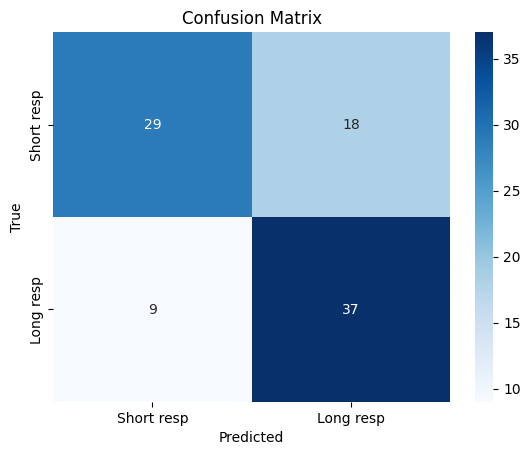

In [14]:
full_pipe.set_params(**study.best_params)

results = cross_validate(
    full_pipe, x, y,
    cv=skf,
    scoring=['roc_auc', 'f1'],
    return_train_score=True,
    n_jobs=-1
)

print(f"Train ROC-AUC : {results['train_roc_auc'].mean():.3f} ± {results['train_roc_auc'].std():.3f}")
print(f"Train  F1     : {results['train_f1'].mean():.3f} ± {results['train_f1'].std():.3f}")
print(f"Test ROC-AUC  : {results['test_roc_auc'].mean():.3f} ± {results['test_roc_auc'].std():.3f}")
print(f"Test F1       : {results['test_f1'].mean():.3f} ± {results['test_f1'].std():.3f}")

y_pred = cross_val_predict(
    full_pipe, x, y, 
    cv=skf,
    n_jobs=-1
)

target_names = ['Short resp', 'Long resp']

print(classification_report(
    y, y_pred,
    target_names=target_names
))

cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=target_names,
            yticklabels=target_names,
            cmap='Blues')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

In [15]:
selected_per_fold = []
for tr, _ in skf.split(x, y):
    full_pipe.fit(x.iloc[tr], y.iloc[tr])
    names = full_pipe['preprocess'].get_feature_names_out()
    coefs = full_pipe['clf'].coef_[0]
    mask = coefs != 0
    selected_per_fold.append(set(names[mask]))

common = set.intersection(*selected_per_fold)
union = set.union(*selected_per_fold)
sizes = [len(s) for s in selected_per_fold]
print(f"Per-fold sizes: {sizes}")
print(f"In all folds:   {len(common)}")
print(f"Union size:     {len(union)}")
print(f"Stability ratio: {len(common) / max(1, min(sizes)):.2f}")

Per-fold sizes: [38, 38, 38, 38, 38]
In all folds:   16
Union size:     98
Stability ratio: 0.42


In [16]:
print(common)

{'age__age', 'drug_braf__V600E', 'drug_braf__dabrafenib', 'drug_braf__V600K', 'categorical__sex_male', 'categorical__sex_female', 'm_stage__M_stage', 'drug_braf__MND', 'drug_braf__vemurafenib', 'drug_braf__cobimetinib', 'gex__ALDH5A1', 'categorical__LDH_elevated', 'categorical__AJCC_stage_IV', 'categorical__AJCC_stage_IIIC', 'categorical__LDH_normal', 'drug_braf__trametinib'}


## Explanability

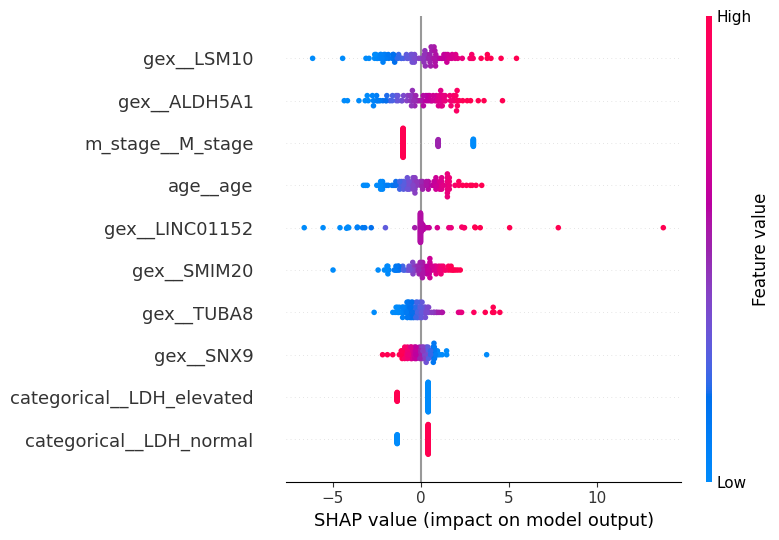

(93, 40)

In [19]:
full_pipe.fit(x, y)

x_transformed = full_pipe[:-1].transform(x)  # x -> prep -> scaler

# Recover feature names after RFE
preprocessed_feature_names = full_pipe['preprocess'].get_feature_names_out()
# selected_mask = full_pipe['selection'].support_
# feature_names = preprocessed_feature_names[selected_mask]
feature_names = preprocessed_feature_names

explainer = shap.LinearExplainer(full_pipe['clf'], x_transformed)
shap_values = explainer(x_transformed)
shap_values.feature_names = feature_names.tolist()

shap.summary_plot(shap_values, x_transformed, feature_names=feature_names, max_display=10)
x_transformed.shape


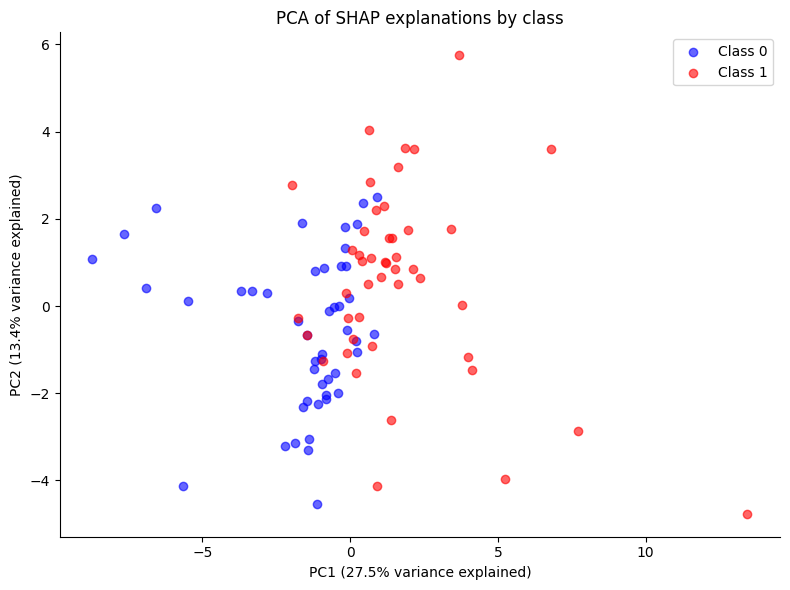

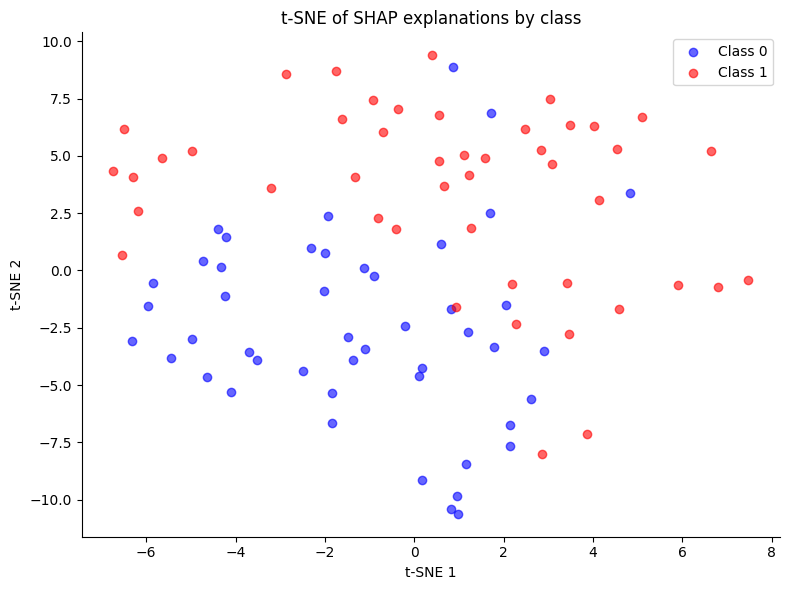

/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


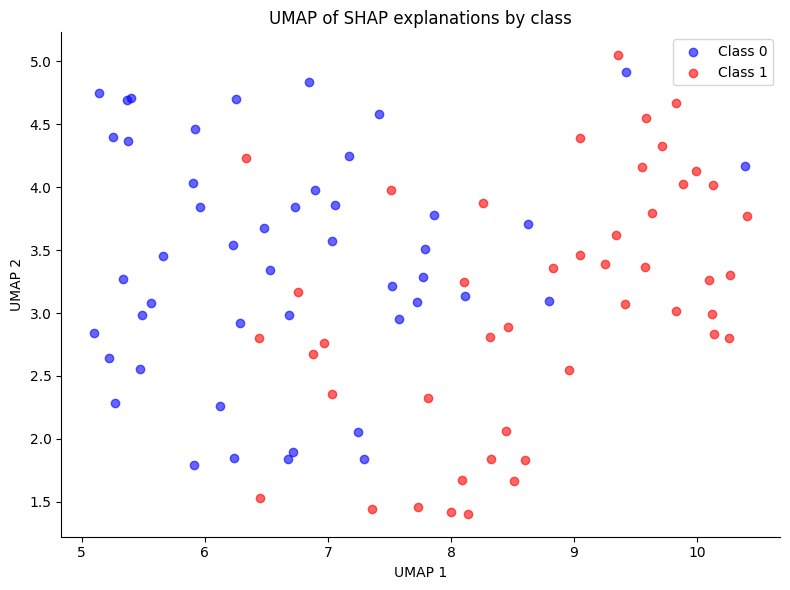

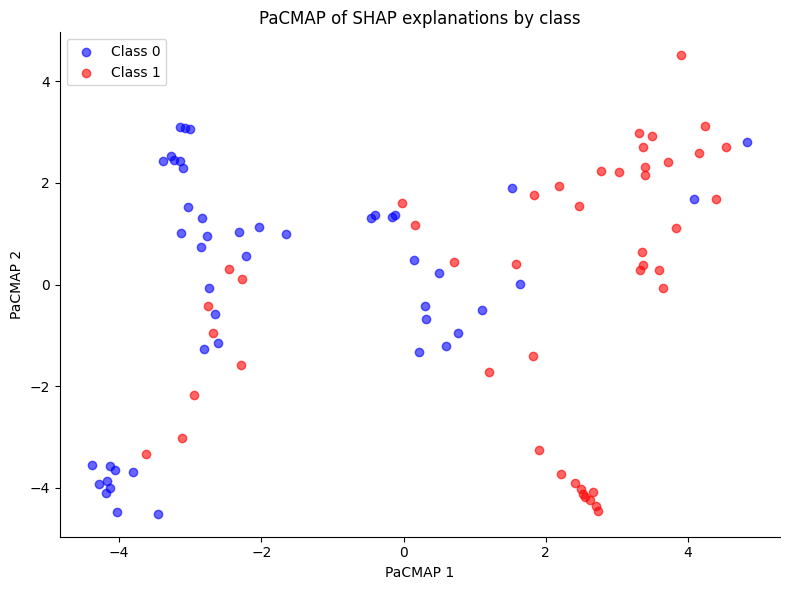

In [18]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import pacmap

def plot_shap_reduction(sv_2d, y_arr, method_name="PCA", var=None):
    colors = {0: "blue", 1: "red"}
    labels = {0: "Class 0", 1: "Class 1"}

    fig, ax = plt.subplots(figsize=(8, 6))

    for cls in [0, 1]:
        mask = y_arr == cls     # boolean
        ax.scatter(
            sv_2d[mask, 0], sv_2d[mask, 1],
            c=colors[cls], label=labels[cls],
            alpha=0.6,
        )

    if var is not None:
        ax.set_xlabel(f"PC1 ({var[0]:.1%} variance explained)")
        ax.set_ylabel(f"PC2 ({var[1]:.1%} variance explained)")
    else:
        ax.set_xlabel(f"{method_name} 1")
        ax.set_ylabel(f"{method_name} 2")

    ax.set_title(f"{method_name} of SHAP explanations by class")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()
    
y_arr = np.array(y)  
    
# PCA — pass explained variance
pca = PCA(n_components=2)
sv_2d = pca.fit_transform(shap_values.values)
plot_shap_reduction(sv_2d, y_arr, method_name="PCA", var=pca.explained_variance_ratio_)

# t-SNE
tsne = TSNE(n_components=2, perplexity=20, random_state=42)
sv_2d = tsne.fit_transform(shap_values.values)
plot_shap_reduction(sv_2d, y_arr, method_name="t-SNE")
 
# UMAP
u_map = umap.UMAP(n_components=2, random_state=42)
sv_2d = u_map.fit_transform(shap_values.values)
plot_shap_reduction(sv_2d, y_arr, method_name="UMAP")

# PaCMAP
pac_map = pacmap.PaCMAP(n_components=2, random_state=42)
sv_2d = pac_map.fit_transform(shap_values.values)
plot_shap_reduction(sv_2d, y_arr, method_name="PaCMAP")
